# The first three minutes: GW150914, in the data

This is the signal that arrived on 14 September 2015, in the data that anyone
can download. Nothing here is a simulation: it is 32 seconds of the strain
recorded by the two LIGO detectors, read from the files in `demo/data/`.

Run the cells in order. The whole notebook takes about a minute.

In [1]:
import warnings
warnings.filterwarnings("ignore")   # keep the screen clean

import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

MERGER = 1126259462.4        # when the two black holes met, in GPS seconds

hanford = TimeSeries.read("data/gw150914_H1.hdf5", format="hdf5.gwosc")
livingston = TimeSeries.read("data/gw150914_L1.hdf5", format="hdf5.gwosc")

print(f"{hanford.duration} of data at {hanford.sample_rate}")
print(f"the two detectors are 3000 km apart")

32.0 s of data at 4096.0 Hz
the two detectors are 3000 km apart


## 1. The data as it comes

The signal is in here. Look at it.

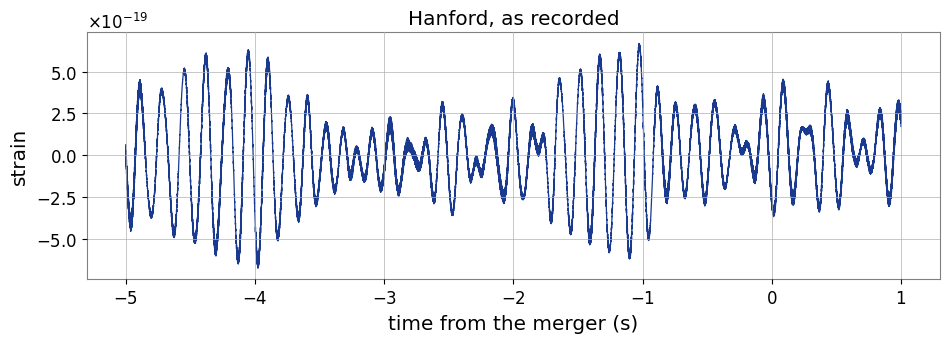

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
piece = hanford.crop(MERGER - 5, MERGER + 1)
ax.plot(piece.times.value - MERGER, piece.value, color="#1A3A8F", lw=0.9)  # palette BLUE
ax.set_xlabel("time from the merger (s)")
ax.set_ylabel("strain")
ax.set_title("Hanford, as recorded")
fig.tight_layout()

You see nothing, and that is the honest picture. The instrument shakes far
more at low frequency than the signal ever does, so the wave is buried under
noise that has nothing to do with the sky.

## 2. The same data, weighted by the noise

Two steps. **Whitening** divides every frequency by how noisy the instrument is
there, so no frequency is allowed to shout over the others. Then we keep the
band between 35 and 350 hertz, which is where this signal lives.

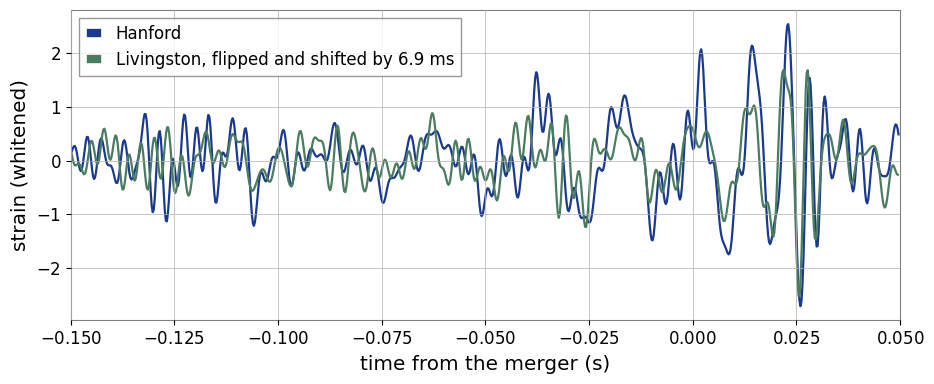

In [3]:
hanford_w = hanford.whiten(4, 2).bandpass(35, 350)
livingston_w = -livingston.whiten(4, 2).bandpass(35, 350)
livingston_w.shift("6.9ms")   # Livingston saw it 6.9 ms before Hanford

fig, ax = plt.subplots(figsize=(9.5, 4))
# the two colours are the course palette, BLUE and SAGE
for series, name, colour in (
        (hanford_w, "Hanford", "#1A3A8F"),
        (livingston_w, "Livingston, flipped and shifted by 6.9 ms", "#4A7C5F")):
    piece = series.crop(MERGER - 0.15, MERGER + 0.05)
    ax.plot(piece.times.value - MERGER, piece.value, lw=1.6, color=colour,
            label=name)
ax.set_xlabel("time from the merger (s)")
ax.set_ylabel("strain (whitened)")
ax.set_xlim(-0.15, 0.05)
ax.legend(loc="upper left")
fig.tight_layout()

The same shape comes out of two instruments 3000 kilometres apart, inside the
ten milliseconds light needs to travel between them. Livingston is drawn upside
down because the two detectors are built at different angles on the Earth, and
moved back by the 6.9 milliseconds the wave took to cross from one to the
other.

## 3. The same seconds, in time and frequency

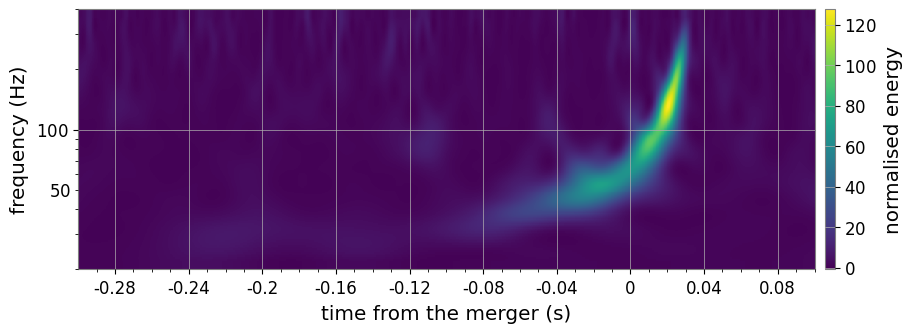

In [4]:
spectrogram = hanford.q_transform(outseg=(MERGER - 0.3, MERGER + 0.1),
                                  frange=(20, 400))

fig = spectrogram.plot(figsize=(9.5, 4))
ax = fig.gca()
ax.set_yscale("log")
ax.set_epoch(MERGER)
ax.set_xlabel("time from the merger (s)")
ax.set_ylabel("frequency (Hz)")
fig.colorbar(label="normalised energy")

The frequency climbs and the signal gets louder, then it stops. Two black
holes, about 36 and 29 times the mass of the Sun, spiralling into one another
and merging into a single one of about 62. The three missing solar masses left
as gravitational waves, in two tenths of a second.

You will do all of this yourself, and more carefully, in the laboratories of
this course: whitening, the time–frequency picture, and then matched filtering
against a bank of templates to measure the masses.

*Data: LIGO Open Science Center, GW150914, release R1 —
[gwosc.org](https://gwosc.org/eventapi/html/GWTC-1-confident/GW150914/).
32 s of strain at 4096 Hz from each detector, as published.*